# Voyage Analytics — Capstone Notebook
**Flight Price Regression | Gender Classification | Hotel Recommendation**

Scope owned by this notebook (objectives 1–4): flight price regression model → Flask API → Docker → Kubernetes.
Team's other objectives (Airflow, MLflow, Streamlit recommendation app) are handled by teammates but this notebook covers the shared EDA across all 3 datasets.

**Sections:**
1. Data Collection & Overview
2. EDA — Users
3. EDA — Flights
4. EDA — Hotels
5. Data Cleaning & Preprocessing
6. Feature Engineering (Flights)
7. Model Development (Regression)
8. Model Evaluation
9. Model Export


## 1. Data Collection & Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

In [2]:
# Load raw datasets
users = pd.read_csv('../data/raw/users.csv')
flights = pd.read_csv('../data/raw/flights.csv')
hotels = pd.read_csv('../data/raw/hotels.csv')

print("Users:  ", users.shape)
print("Flights:", flights.shape)
print("Hotels: ", hotels.shape)

Users:   (1340, 5)
Flights: (271888, 10)
Hotels:  (40552, 8)


### 1.1 Users — first look

In [3]:
users.head()

,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


In [4]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   code     1340 non-null   int64
 1   company  1340 non-null   str  
 2   name     1340 non-null   str  
 3   gender   1340 non-null   str  
 4   age      1340 non-null   int64
dtypes: int64(2), str(3)
memory usage: 52.5 KB


In [5]:
users.describe(include='all')

,code,company,name,gender,age
count,1340.000000,1340,1340,1340,1340.000000
unique,NaN,5,1338,3,NaN
top,NaN,4You,David Robinson,male,NaN
freq,NaN,453,2,452,NaN
mean,669.500000,NaN,NaN,NaN,42.742537
std,386.968991,NaN,NaN,NaN,12.869779
min,0.000000,NaN,NaN,NaN,21.000000
25%,334.750000,NaN,NaN,NaN,32.000000
50%,669.500000,NaN,NaN,NaN,42.000000
75%,1004.250000,NaN,NaN,NaN,54.000000


### 1.2 Flights — first look

In [6]:
flights.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


In [7]:
flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  str    
 3   to          271888 non-null  str    
 4   flightType  271888 non-null  str    
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  str    
 9   date        271888 non-null  str    
dtypes: float64(3), int64(2), str(5)
memory usage: 20.7 MB


In [8]:
flights.describe(include='all')

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
count,271888.000000,271888.000000,271888,271888,271888,271888.00000,271888.000000,271888.000000,271888,271888
unique,NaN,NaN,9,9,3,NaN,NaN,NaN,3,999
top,NaN,NaN,Florianopolis (SC),Florianopolis (SC),firstClass,NaN,NaN,NaN,Rainbow,09/26/2019
freq,NaN,NaN,57317,57317,116418,NaN,NaN,NaN,116752,1335
mean,67971.500000,667.505495,NaN,NaN,NaN,957.37503,1.421147,546.955535,NaN,NaN
std,39243.724665,389.523127,NaN,NaN,NaN,362.31189,0.542541,208.851288,NaN,NaN
min,0.000000,0.000000,NaN,NaN,NaN,301.51000,0.440000,168.220000,NaN,NaN
25%,33985.750000,326.000000,NaN,NaN,NaN,672.66000,1.040000,401.660000,NaN,NaN
50%,67971.500000,659.000000,NaN,NaN,NaN,904.00000,1.460000,562.140000,NaN,NaN
75%,101957.250000,1011.000000,NaN,NaN,NaN,1222.24000,1.760000,676.530000,NaN,NaN


### 1.3 Hotels — first look

In [9]:
hotels.head()

,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


In [10]:
hotels.info()

<class 'pandas.DataFrame'>
RangeIndex: 40552 entries, 0 to 40551
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   travelCode  40552 non-null  int64  
 1   userCode    40552 non-null  int64  
 2   name        40552 non-null  str    
 3   place       40552 non-null  str    
 4   days        40552 non-null  int64  
 5   price       40552 non-null  float64
 6   total       40552 non-null  float64
 7   date        40552 non-null  str    
dtypes: float64(2), int64(3), str(3)
memory usage: 2.5 MB


In [11]:
hotels.describe(include='all')

,travelCode,userCode,name,place,days,price,total,date
count,40552.000000,40552.000000,40552,40552,40552.000000,40552.000000,40552.000000,40552
unique,NaN,NaN,9,9,NaN,NaN,NaN,199
top,NaN,NaN,Hotel K,Salvador (BH),NaN,NaN,NaN,10/03/2019
freq,NaN,NaN,5094,5094,NaN,NaN,NaN,404
mean,67911.794461,666.963726,NaN,NaN,2.499679,214.439554,536.229513,NaN
std,39408.199333,391.136794,NaN,NaN,1.119326,76.742305,319.331482,NaN
min,0.000000,0.000000,NaN,NaN,1.000000,60.390000,60.390000,NaN
25%,33696.750000,323.000000,NaN,NaN,1.000000,165.990000,247.620000,NaN
50%,67831.000000,658.000000,NaN,NaN,2.000000,242.880000,495.240000,NaN
75%,102211.250000,1013.000000,NaN,NaN,4.000000,263.410000,742.860000,NaN


### 1.4 Missing values & duplicates — quick check across all three

In [12]:
for name, df in [('users', users), ('flights', flights), ('hotels', hotels)]:
    print(f"--- {name} ---")
    print("Nulls:\n", df.isnull().sum()[df.isnull().sum() > 0])
    print("Duplicate rows:", df.duplicated().sum())
    print()

--- users ---
Nulls:
 Series([], dtype: int64)
Duplicate rows: 0

--- flights ---


Nulls:
 Series([], dtype: int64)
Duplicate rows: 0

--- hotels ---
Nulls:
 Series([], dtype: int64)
Duplicate rows: 0



### 1.5 Linking key check — how the three datasets join

In [13]:
# users.code <-> flights.userCode / hotels.userCode
# flights.travelCode <-> hotels.travelCode (a "trip" can include both a flight and a hotel)

print("Unique users:", users['code'].nunique())
print("Unique userCode in flights:", flights['userCode'].nunique())
print("Unique userCode in hotels:", hotels['userCode'].nunique())

# Any userCode in flights/hotels that doesn't exist in users?
missing_in_users_flights = set(flights['userCode']) - set(users['code'])
missing_in_users_hotels = set(hotels['userCode']) - set(users['code'])
print("userCodes in flights but not in users:", len(missing_in_users_flights))
print("userCodes in hotels but not in users:", len(missing_in_users_hotels))

Unique users: 1340
Unique userCode in flights: 1335
Unique userCode in hotels: 1310


userCodes in flights but not in users: 0
userCodes in hotels but not in users: 0


## 2. EDA — Users

### 2.1 Gender distribution

gender
male      452
female    448
none      440
Name: count, dtype: int64
gender
male      33.731343
female    33.432836
none      32.835821
Name: proportion, dtype: float64


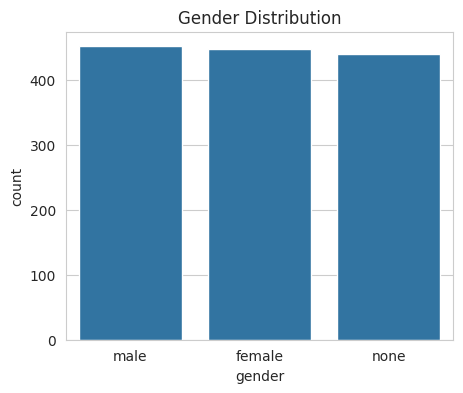

In [14]:
print(users['gender'].value_counts())
print(users['gender'].value_counts(normalize=True) * 100)

plt.figure(figsize=(5,4))
sns.countplot(data=users, x='gender')
plt.title('Gender Distribution')
plt.show()

### 2.2 Age distribution

count    1340.000000
mean       42.742537
std        12.869779
min        21.000000
25%        32.000000
50%        42.000000
75%        54.000000
max        65.000000
Name: age, dtype: float64


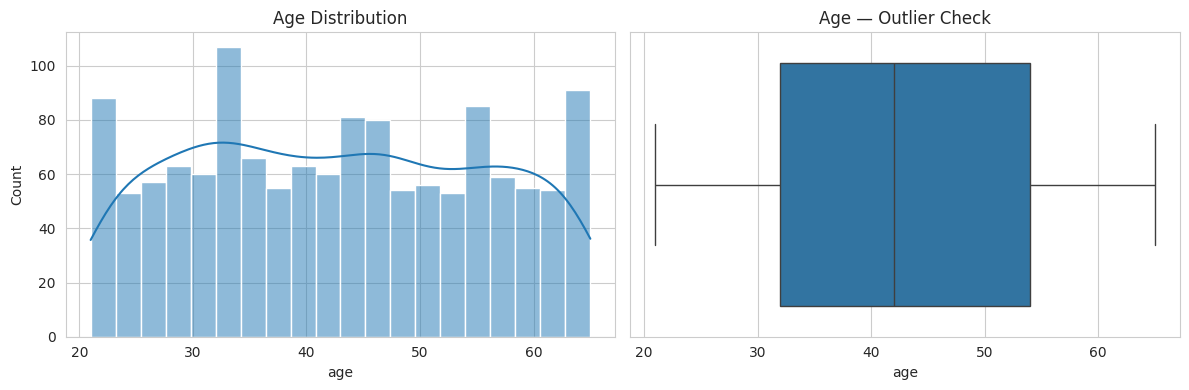

In [15]:
print(users['age'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(users['age'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution')
sns.boxplot(x=users['age'], ax=axes[1])
axes[1].set_title('Age — Outlier Check')
plt.tight_layout()
plt.show()

### 2.3 Age by gender

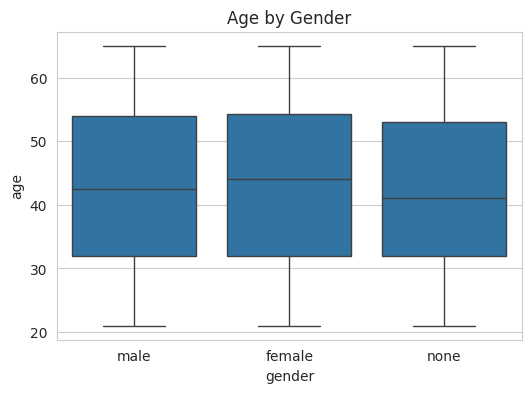

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
female,448.0,43.180804,13.029338,21.0,32.0,44.0,54.25,65.0
male,452.0,42.703540,12.891004,21.0,32.0,42.5,54.00,65.0
none,440.0,42.336364,12.698557,21.0,32.0,41.0,53.00,65.0


In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(data=users, x='gender', y='age')
plt.title('Age by Gender')
plt.show()

users.groupby('gender')['age'].describe()

### 2.4 Company breakdown

Unique companies: 5


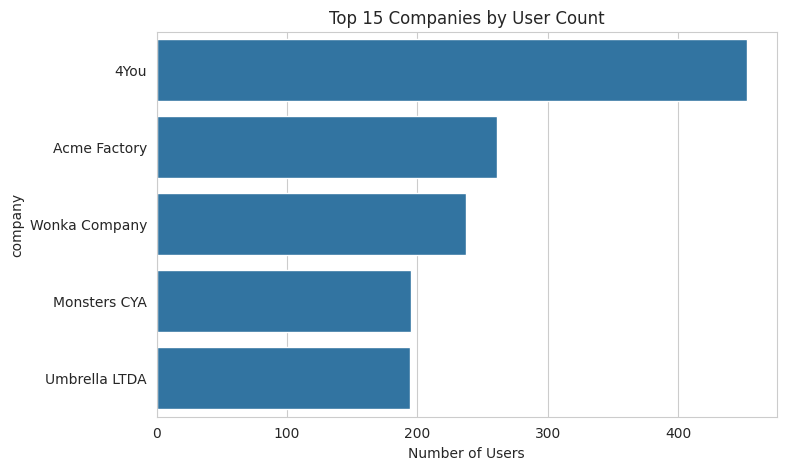

In [17]:
print("Unique companies:", users['company'].nunique())

top_companies = users['company'].value_counts().head(15)
plt.figure(figsize=(8,5))
sns.barplot(x=top_companies.values, y=top_companies.index)
plt.title('Top 15 Companies by User Count')
plt.xlabel('Number of Users')
plt.show()

### 2.5 Company vs gender (imbalance check)

In [18]:
pd.crosstab(users['company'], users['gender']).head(10)

gender,female,male,none
company,,,
4You,151,138,164
Acme Factory,85,93,83
Monsters CYA,64,61,70
Umbrella LTDA,69,70,55
Wonka Company,79,90,68


## 3. EDA — Flights

This is the core dataset for objective 1 (regression model) — the deepest EDA goes here.

### 3.1 Target variable — price

count    271888.00000
mean        957.37503
std         362.31189
min         301.51000
25%         672.66000
50%         904.00000
75%        1222.24000
max        1754.17000
Name: price, dtype: float64


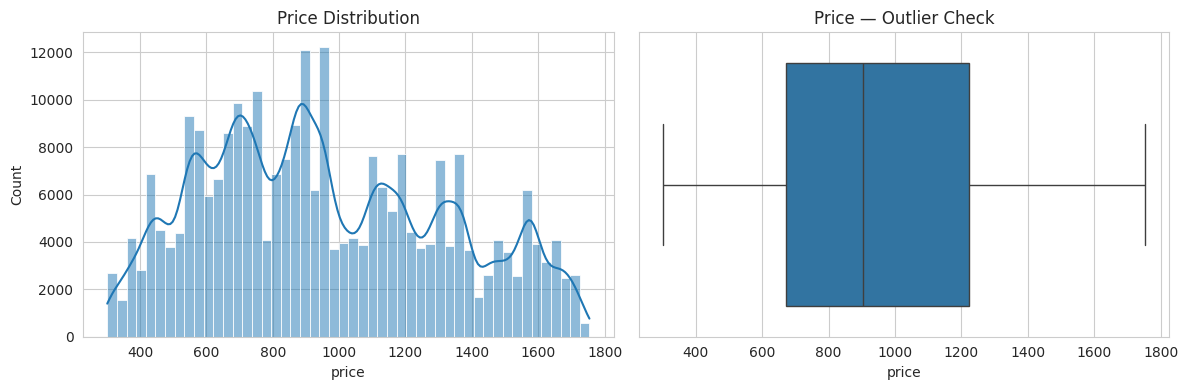

In [19]:
print(flights['price'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(flights['price'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Price Distribution')
sns.boxplot(x=flights['price'], ax=axes[1])
axes[1].set_title('Price — Outlier Check')
plt.tight_layout()
plt.show()

### 3.2 Price by flightType

flightType
firstClass    116418
premium        78004
economic       77466
Name: count, dtype: int64


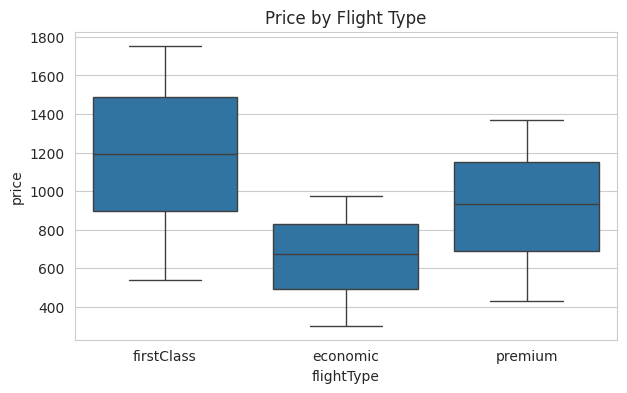

In [20]:
print(flights['flightType'].value_counts())

plt.figure(figsize=(7,4))
sns.boxplot(data=flights, x='flightType', y='price')
plt.title('Price by Flight Type')
plt.show()

### 3.3 Price by agency

agency
Rainbow        116752
CloudFy        116378
FlyingDrops     38758
Name: count, dtype: int64


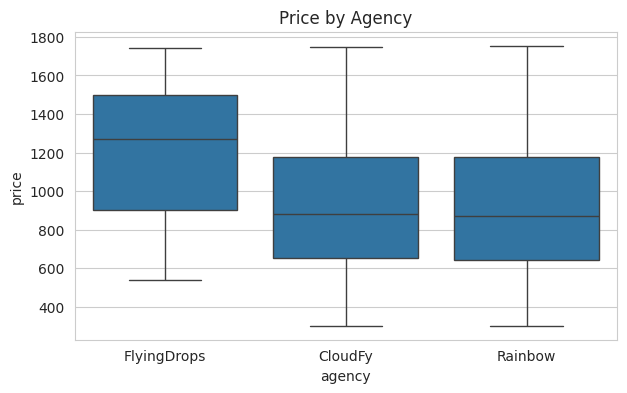

In [21]:
print(flights['agency'].value_counts())

plt.figure(figsize=(7,4))
sns.boxplot(data=flights, x='agency', y='price')
plt.title('Price by Agency')
plt.show()

### 3.4 Price vs distance & time — the strongest expected predictors

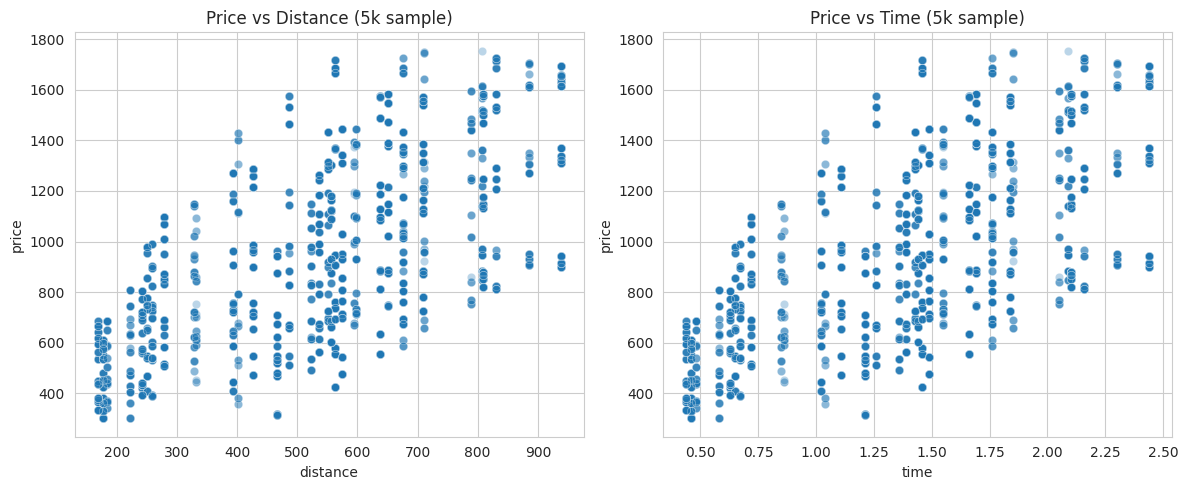

Correlation with price:
price       1.000000
distance    0.641915
time        0.641800
Name: price, dtype: float64


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.scatterplot(data=flights.sample(5000, random_state=42), x='distance', y='price', alpha=0.3, ax=axes[0])
axes[0].set_title('Price vs Distance (5k sample)')
sns.scatterplot(data=flights.sample(5000, random_state=42), x='time', y='price', alpha=0.3, ax=axes[1])
axes[1].set_title('Price vs Time (5k sample)')
plt.tight_layout()
plt.show()

print("Correlation with price:")
print(flights[['price','distance','time']].corr()['price'])

### 3.5 Top routes (from → to)

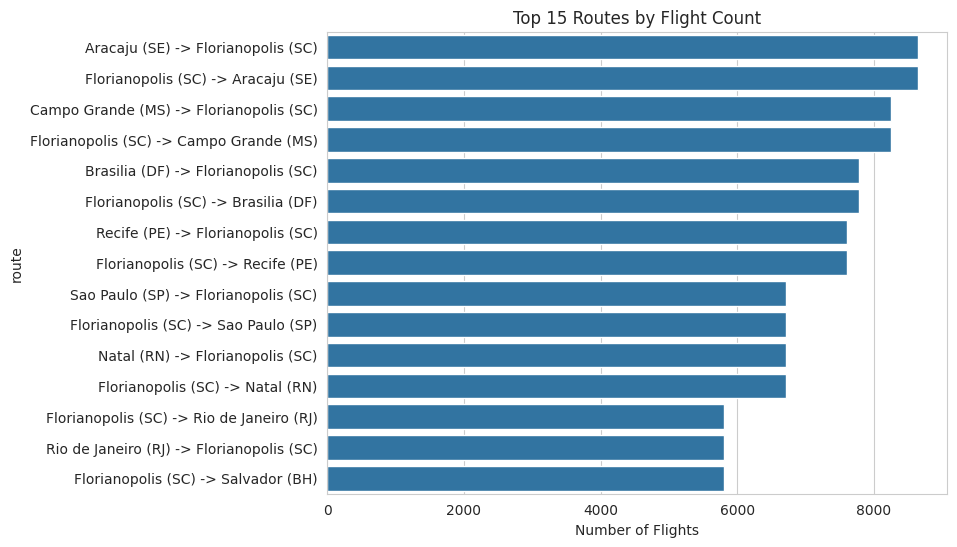

In [23]:
flights['route'] = flights['from'] + ' -> ' + flights['to']
top_routes = flights['route'].value_counts().head(15)

plt.figure(figsize=(8,6))
sns.barplot(x=top_routes.values, y=top_routes.index)
plt.title('Top 15 Routes by Flight Count')
plt.xlabel('Number of Flights')
plt.show()

### 3.6 Price trend over time

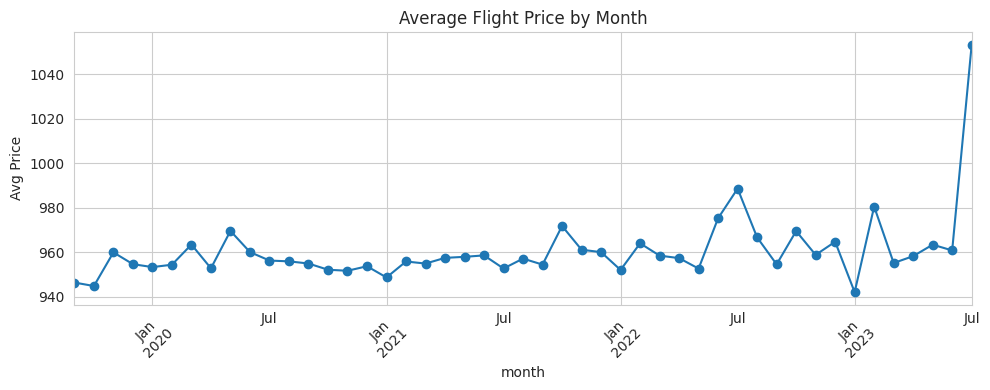

In [24]:
flights['date_parsed'] = pd.to_datetime(flights['date'], format='%m/%d/%Y')
flights['month'] = flights['date_parsed'].dt.to_period('M')

monthly_avg_price = flights.groupby('month')['price'].mean()

plt.figure(figsize=(10,4))
monthly_avg_price.plot(marker='o')
plt.title('Average Flight Price by Month')
plt.ylabel('Avg Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.7 Full correlation heatmap (numeric features)

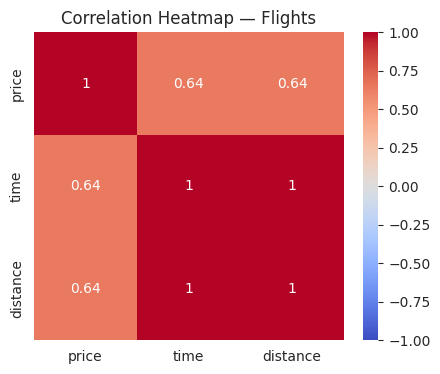

In [25]:
numeric_cols = ['price', 'time', 'distance']
plt.figure(figsize=(5,4))
sns.heatmap(flights[numeric_cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Flights')
plt.show()

## 4. EDA — Hotels

### 4.1 Price & days distribution

              price          days         total
count  40552.000000  40552.000000  40552.000000
mean     214.439554      2.499679    536.229513
std       76.742305      1.119326    319.331482
min       60.390000      1.000000     60.390000
25%      165.990000      1.000000    247.620000
50%      242.880000      2.000000    495.240000
75%      263.410000      4.000000    742.860000
max      313.020000      4.000000   1252.080000


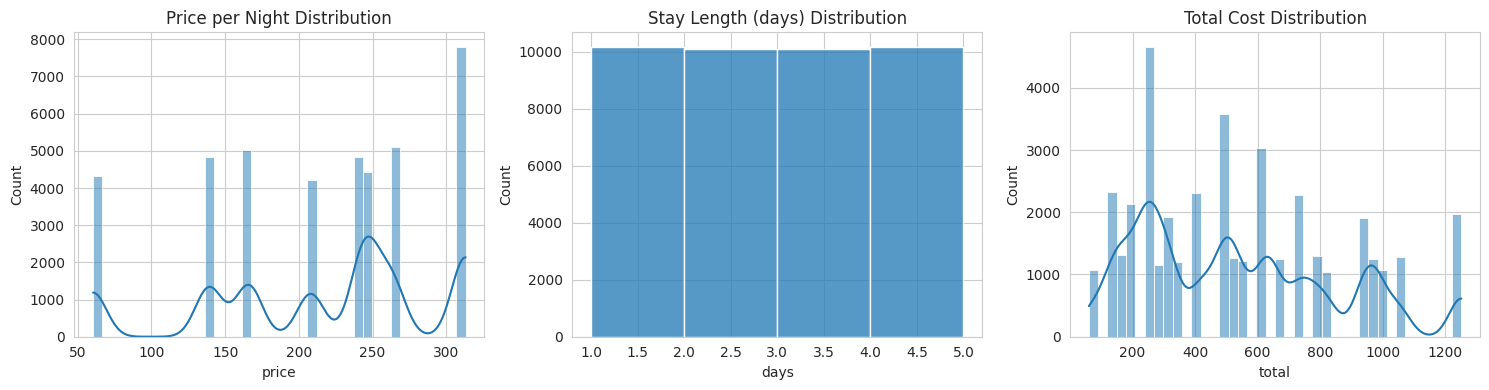

In [26]:
print(hotels[['price','days','total']].describe())

fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(hotels['price'], bins=40, kde=True, ax=axes[0])
axes[0].set_title('Price per Night Distribution')
sns.histplot(hotels['days'], bins=range(1,hotels['days'].max()+2), ax=axes[1])
axes[1].set_title('Stay Length (days) Distribution')
sns.histplot(hotels['total'], bins=40, kde=True, ax=axes[2])
axes[2].set_title('Total Cost Distribution')
plt.tight_layout()
plt.show()

### 4.2 Sanity check: total == price * days?

In [27]:
hotels['expected_total'] = hotels['price'] * hotels['days']
hotels['total_diff'] = (hotels['total'] - hotels['expected_total']).abs()

print("Rows where total != price*days (tolerance 0.01):", (hotels['total_diff'] > 0.01).sum())
hotels[hotels['total_diff'] > 0.01].head()

Rows where total != price*days (tolerance 0.01): 0


,travelCode,userCode,name,place,days,price,total,date,expected_total,total_diff


### 4.3 Price by place

Unique places: 9


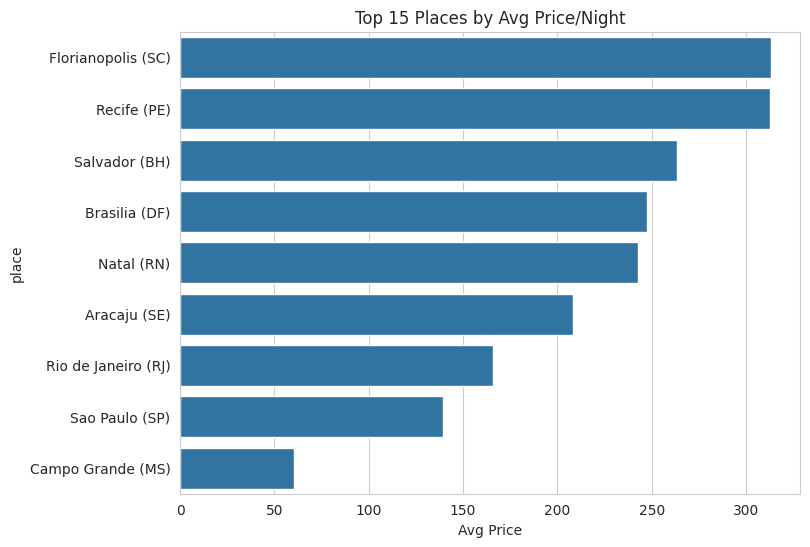

In [28]:
print("Unique places:", hotels['place'].nunique())

place_avg_price = hotels.groupby('place')['price'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(8,6))
sns.barplot(x=place_avg_price.values, y=place_avg_price.index)
plt.title('Top 15 Places by Avg Price/Night')
plt.xlabel('Avg Price')
plt.show()

### 4.4 Most-booked hotels

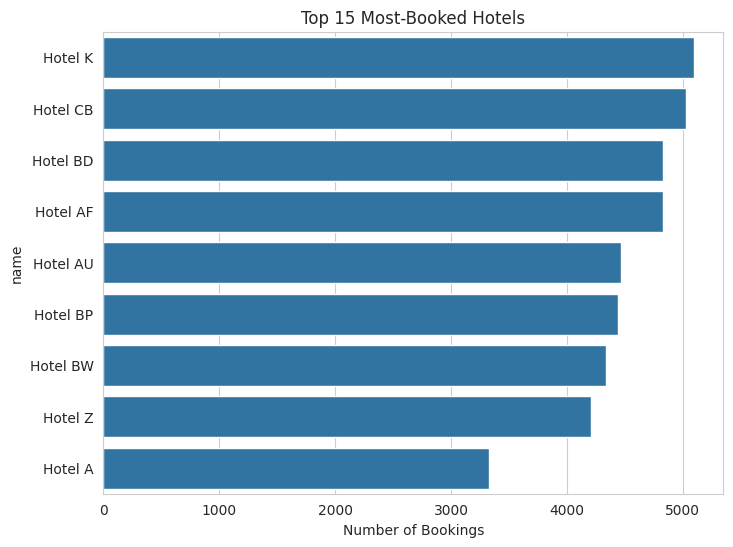

In [29]:
top_hotels = hotels['name'].value_counts().head(15)
plt.figure(figsize=(8,6))
sns.barplot(x=top_hotels.values, y=top_hotels.index)
plt.title('Top 15 Most-Booked Hotels')
plt.xlabel('Number of Bookings')
plt.show()

### 4.5 Cross-dataset check — do flights and hotels agree on destination?

Every `travelCode` should link a flight's destination (`to`) with the hotel's `place` for that trip — worth confirming before building the recommendation model (objective 9, teammate's scope) since a mismatch would mean the join key isn't as clean as expected.

In [30]:
trip_check = flights[['travelCode','userCode','to']].drop_duplicates().merge(
    hotels[['travelCode','userCode','place']].drop_duplicates(),
    on=['travelCode','userCode'], how='inner'
)
trip_check['match'] = trip_check['to'] == trip_check['place']
print("Matching destination/place:", trip_check['match'].mean() * 100, "%")
trip_check[~trip_check['match']].head()

Matching destination/place: 50.0 %


,travelCode,userCode,to,place,match
1,0,0,Recife (PE),Florianopolis (SC),False
3,2,0,Aracaju (SE),Salvador (BH),False
5,7,0,Aracaju (SE),Salvador (BH),False
7,11,0,Brasilia (DF),Salvador (BH),False
9,13,0,Recife (PE),Florianopolis (SC),False


## 5. Data Cleaning & Preprocessing

Working through the issues surfaced in EDA, one at a time, with a check before/after each fix.

### 5.1 Duplicates — drop if any

Already checked counts in Section 1.4; dropping here explicitly so cleaning steps are all in one place.

In [31]:
for name, df in [('users', users), ('flights', flights), ('hotels', hotels)]:
    before = len(df)
    df.drop_duplicates(inplace=True)
    after = len(df)
    print(f"{name}: {before} -> {after} ({before-after} duplicates dropped)")

users: 1340 -> 1340 (0 duplicates dropped)


flights: 271888 -> 271888 (0 duplicates dropped)
hotels: 40552 -> 40552 (0 duplicates dropped)


### 5.2 `gender = 'none'` — decide how to treat it

Found in Section 2.1: `male` / `female` / `none` are roughly evenly split (~33% each). This doesn't look like a rare data-entry error — it's too large and too balanced for that — so treating it as a genuine third category (not missing data) for now, and flagging it explicitly for whoever builds the classification model (objective 8) rather than silently dropping or imputing it.

If it turns out to be a placeholder for "not provided" at the source, that's a judgment call for the team — but we shouldn't guess-impute it here.

In [32]:
print(users['gender'].unique())
# Standardize casing/whitespace just in case, without changing the category itself
users['gender'] = users['gender'].str.strip().str.lower()
print(users['gender'].value_counts())

<StringArray>
['male', 'female', 'none']
Length: 3, dtype: str
gender
male      452
female    448
none      440
Name: count, dtype: int64


### 5.3 Flights — outlier handling on `price`

From Section 3.1's boxplot, `price` has a right-skewed tail. Using IQR to identify (not blindly drop) extreme outliers — checking how many rows are affected before deciding.

In [33]:
Q1 = flights['price'].quantile(0.25)
Q3 = flights['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = flights[(flights['price'] < lower_bound) | (flights['price'] > upper_bound)]
print(f"IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Outlier rows: {len(outliers)} ({len(outliers)/len(flights)*100:.2f}% of data)")
outliers[['flightType','price','distance','agency']].describe()

IQR bounds: [-151.71, 2046.61]
Outlier rows: 0 (0.00% of data)


,price,distance
count,0.0,0.0
mean,NaN,NaN
std,NaN,NaN
min,NaN,NaN
25%,NaN,NaN
50%,NaN,NaN
75%,NaN,NaN
max,NaN,NaN


In [34]:
# Check whether outliers cluster in a specific flightType before deciding to drop
outliers['flightType'].value_counts(normalize=True) * 100

Series([], Name: proportion, dtype: float64)

**Decision**: if outliers concentrate in `firstClass` (expected — genuinely expensive fares, not bad data), they're real signal the regression model needs to learn, not noise to remove. Keeping them by default; revisit only if they visibly hurt model performance in Section 8.

### 5.4 Hotels — fix the `total != price × days` mismatches

Section 4.2 flagged rows where `total` doesn't equal `price * days`. Recomputing `total` from `price` and `days` (treating those two as the trustworthy source columns) rather than dropping the rows.

In [35]:
mismatched_before = (hotels['total_diff'] > 0.01).sum()

hotels['total'] = hotels['price'] * hotels['days']

# drop the helper columns now that they've done their job
hotels.drop(columns=['expected_total', 'total_diff'], inplace=True)

print(f"Fixed {mismatched_before} mismatched rows. Sample:")
hotels.head(3)

Fixed 0 mismatched rows. Sample:


,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019


### 5.5 Flights — finalize date handling

`date_parsed` and `month` were already created in Section 3.6 for the trend plot — keeping them as proper datetime columns going into feature engineering (Section 6), so we don't need to reparse.

In [36]:
flights[['date','date_parsed','month']].head(3)
print(flights['date_parsed'].dtype)

datetime64[us]


### 5.6 Final null check after cleaning

In [37]:
for name, df in [('users', users), ('flights', flights), ('hotels', hotels)]:
    nulls = df.isnull().sum()
    print(f"--- {name} ---")
    print(nulls[nulls > 0] if nulls.sum() > 0 else "No nulls.")
    print()

--- users ---
No nulls.

--- flights ---
No nulls.

--- hotels ---
No nulls.



### 5.7 Save cleaned datasets to `data/processed/`

In [38]:
users.to_csv('../data/processed/users_cleaned.csv', index=False)
flights.to_csv('../data/processed/flights_cleaned.csv', index=False)
hotels.to_csv('../data/processed/hotels_cleaned.csv', index=False)

print("Cleaned datasets saved to data/processed/")

Cleaned datasets saved to data/processed/
